# EC523 Project — Speech Denoising

Tamerlan Baimurat, Punnisa Amornsirikul, Jiaxing Wang, Michael Lwe

{baimurat, punnisa, jiaxingw, mlwe}@bu.edu

Spring 2026


**Dataset:** 23,075 training + 824 test paired clean/noisy utterances (16 kHz, mono).
All audio has been preprocessed to complex STFT tensors (`complex64`, shape `[257, T]`) and served via a public HTTP endpoint: https://ec523.tamerlanbaimurat.com.

**Goal:** Build and train a neural network that takes a noisy STFT spectrogram as input and produces a denoised (clean) spectrogram as output.

# 1. Setup

This section loads all required libaries for our project.

In [15]:
!pip install flash-linear-attention

In [16]:
from __future__ import print_function
import io
import json
import os
import random
import threading
import time
from urllib.parse import quote

import matplotlib.pyplot as plt
import numpy as np
import requests
from requests.adapters import HTTPAdapter
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from fla.layers import DeltaNet

In [17]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Random seed set to {seed}")

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Random seed set to 42
Device: cuda


# 2. Retrieving Data

The following Python script retrives the training and testing dataset from our HTML endpoint, https://ec523.tamerlanbaimurat.com.

In [18]:
BASE_URL = "https://ec523.tamerlanbaimurat.com"
PREFIX   = "ec523project"
MAX_RETRIES = 5

def public_url(key: str) -> str:
    return f"{BASE_URL}/{quote(key.lstrip('/'), safe='/')}"

_local = threading.local()

def _session() -> requests.Session:
    if not hasattr(_local, "s"):
        s = requests.Session()
        adapter = HTTPAdapter(pool_connections=64, pool_maxsize=64)
        s.mount("https://", adapter)
        _local.s = s
    return _local.s

def fetch_bytes(key: str, timeout: int = 60) -> bytes:
    for attempt in range(MAX_RETRIES):
        try:
            r = _session().get(public_url(key), timeout=timeout)
            if r.status_code == 503:
                raise requests.exceptions.ConnectionError("503")
            r.raise_for_status()
            return r.content
        except (requests.exceptions.ConnectionError,
                requests.exceptions.Timeout,
                requests.exceptions.HTTPError):
            if attempt == MAX_RETRIES - 1:
                raise
            time.sleep(2 ** attempt + random.random())
    return b""

def fetch_manifest(split: str) -> list[dict]:
    key = f"{PREFIX}/manifests/{split}.jsonl"
    text = fetch_bytes(key).decode()
    return [json.loads(line) for line in text.splitlines() if line.strip()]


class AdaptivePool:
    """AIMD concurrency: starts fast, backs off on 503, recovers quickly."""

    def __init__(self, initial=32, minimum=4, maximum=64, grow_every=20):
        self._sem_value = initial
        self._sem = threading.Semaphore(initial)
        self._lock = threading.Lock()
        self._min = minimum
        self._max = maximum
        self._grow_every = grow_every
        self.successes = 0
        self.errors = 0

    @property
    def window(self):
        return self._sem_value

    def acquire(self):
        self._sem.acquire()

    def release_success(self):
        with self._lock:
            self.successes += 1
            if self.successes % self._grow_every == 0 and self._sem_value < self._max:
                self._sem_value += 1
                self._sem.release()
                return
        self._sem.release()

    def release_error(self):
        with self._lock:
            self.errors += 1
            new = max(self._sem_value // 2, self._min)
            while self._sem_value > new:
                self._sem.acquire(blocking=False) or None
                self._sem_value -= 1
        self._sem.release()


class STFTDataset(Dataset):
    """Fetches clean/noisy STFT pairs from HTTP, with in-memory caching."""

    def __init__(self, records: list[dict], split: str):
        self.records = records
        self.split = split
        self._cache: dict[int, tuple[torch.Tensor, torch.Tensor]] = {}

    @classmethod
    def from_manifest(cls, split: str) -> "STFTDataset":
        records = fetch_manifest(split)
        print(f"[{split}] manifest loaded: {len(records)} pairs")
        return cls(records, split)

    def prefetch_all(self):
        """Download every pair into RAM with adaptive concurrency."""
        from concurrent.futures import ThreadPoolExecutor, as_completed

        to_fetch = [i for i in range(len(self.records)) if i not in self._cache]
        if not to_fetch:
            print(f"[{self.split}] all {len(self.records)} pairs already cached")
            return

        pool = AdaptivePool(initial=32, minimum=4, maximum=128)

        def _download(idx):
            pool.acquire()
            try:
                rec = self.records[idx]
                noisy_bytes = fetch_bytes(rec["noisy_stft_key"])
                clean_bytes = fetch_bytes(rec["clean_stft_key"])
                noisy = torch.load(io.BytesIO(noisy_bytes), map_location="cpu",
                                   weights_only=True)["stft"]
                clean = torch.load(io.BytesIO(clean_bytes), map_location="cpu",
                                   weights_only=True)["stft"]
                pool.release_success()
                return idx, noisy, clean
            except Exception:
                pool.release_error()
                raise

        print(f"[{self.split}] prefetching {len(to_fetch)} pairs "
              f"(adaptive window: {pool.window}→{pool._max}) …")
        t0 = time.perf_counter()
        done, errors = 0, 0

        # Use a large thread pool; AdaptivePool's semaphore controls actual concurrency
        with ThreadPoolExecutor(max_workers=64) as ex:
            futures = {ex.submit(_download, i): i for i in to_fetch}
            for fut in as_completed(futures):
                try:
                    idx, noisy, clean = fut.result()
                    self._cache[idx] = (noisy, clean)
                    done += 1
                except Exception as e:
                    errors += 1
                    if errors <= 3:
                        print(f"  ERROR idx={futures[fut]}: {e}")
                total = done + errors
                if total % 500 == 0 or total == len(to_fetch):
                    elapsed = time.perf_counter() - t0
                    print(f"  {total}/{len(to_fetch)}  {elapsed:.0f}s  "
                          f"{done/max(elapsed,1):.0f} pairs/s  "
                          f"window={pool.window}  errors={errors}")
        elapsed = time.perf_counter() - t0
        print(f"[{self.split}] prefetch done: {done} OK, {errors} errors, "
              f"{elapsed:.0f}s")

        # Sequential retry for any failures
        remaining = [i for i in to_fetch if i not in self._cache]
        if remaining:
            print(f"[{self.split}] retrying {len(remaining)} failures …")
            for idx in remaining:
                try:
                    _, noisy, clean = _download(idx)
                    self._cache[idx] = (noisy, clean)
                except Exception as e:
                    print(f"  SKIP idx={idx}: {e}")

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, idx: int) -> dict:
        rec = self.records[idx]

        if idx in self._cache:
            noisy, clean = self._cache[idx]
        else:
            noisy = torch.load(io.BytesIO(fetch_bytes(rec["noisy_stft_key"])),
                               map_location="cpu", weights_only=True)["stft"]
            clean = torch.load(io.BytesIO(fetch_bytes(rec["clean_stft_key"])),
                               map_location="cpu", weights_only=True)["stft"]
            self._cache[idx] = (noisy, clean)

        return {
            "pair_id":     rec["pair_id"],
            "split":       self.split,
            "sample_rate": int(rec["sample_rate"]),
            "noisy":       noisy,          # complex64 [257, T]
            "clean":       clean,          # complex64 [257, T]
            "length":      noisy.shape[-1],
        }

In [19]:
# train_ds = STFTDataset.from_manifest("train")


# # Download all data into RAM (~30.5 GB for 23K pairs).
# # This takes 500 seconds to fetch
# train_ds.prefetch_all()


In [20]:
test_ds  = STFTDataset.from_manifest("test")
test_ds.prefetch_all()

[test] manifest loaded: 824 pairs
[test] prefetching 824 pairs (adaptive window: 32→128) …
  500/824  6s  86 pairs/s  window=57  errors=0
  824/824  9s  88 pairs/s  window=73  errors=0
[test] prefetch done: 824 OK, 0 errors, 9s


# 3. Data Helpers & DataLoaders

Utilities for converting complex STFT to magnitude/phase, collating variable-length batches, and creating DataLoaders.

In [21]:
def stft_to_mag_phase(stft_complex):
    mag = stft_complex.abs()
    phase = stft_complex.angle()
    return mag, phase

In [22]:
TIME_BUCKETS = [100, 200, 300, 400, 500, 600, 800, 1000, 1200, 1600]

def _bucket_pad(t: int) -> int:
    """Round up to the nearest bucket size so Triton sees fewer unique shapes."""
    for b in TIME_BUCKETS:
        if t <= b:
            return b
    return ((t + 63) // 64) * 64

def collate_magnitude(batch):
    """
    Custom collate that converts complex STFTs to log-magnitude tensors
    and pads to a fixed bucket size (reduces Triton recompilations).

    Returns dict with keys:
        noisy_mag:   [B, 1, 257, T_bucket]  log1p magnitude
        clean_mag:   [B, 1, 257, T_bucket]  log1p magnitude
        noisy_phase: [B, 257, T_bucket]     phase (for reconstruction)
        lengths:     [B]                     original T per sample
        pair_ids:    list[str]
    """
    max_t = max(item["noisy"].shape[-1] for item in batch)
    pad_to = _bucket_pad(max_t)

    noisy_mags, clean_mags, noisy_phases, lengths, pair_ids = [], [], [], [], []

    for item in batch:
        n_mag, n_phase = stft_to_mag_phase(item["noisy"])
        c_mag, _       = stft_to_mag_phase(item["clean"])

        pad_t = pad_to - n_mag.shape[-1]
        n_mag   = F.pad(n_mag, (0, pad_t))
        c_mag   = F.pad(c_mag, (0, pad_t))
        n_phase = F.pad(n_phase, (0, pad_t))

        noisy_mags.append(torch.log1p(n_mag).unsqueeze(0))   # [1, 257, T]
        clean_mags.append(torch.log1p(c_mag).unsqueeze(0))
        noisy_phases.append(n_phase)
        lengths.append(item["length"])
        pair_ids.append(item["pair_id"])

    return {
        "noisy_mag":   torch.stack(noisy_mags),     # [B, 1, 257, T]
        "clean_mag":   torch.stack(clean_mags),      # [B, 1, 257, T]
        "noisy_phase": torch.stack(noisy_phases),    # [B, 257, T]
        "lengths":     torch.tensor(lengths, dtype=torch.int64),
        "pair_ids":    pair_ids,
    }

Creates trainloader and testloader DataLoader objects in batches of BATCH_SIZE, which is currently set to 8.

In [23]:
BATCH_SIZE = 8

# train_loader = DataLoader(
#     train_ds,
#     batch_size=BATCH_SIZE,
#     shuffle=True,
#     collate_fn=collate_magnitude,
#     num_workers=0,   # required: HTTP session is not picklable
# )
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_magnitude,
    num_workers=0,
)

# print(f"Train: {len(train_ds)} samples, {len(train_loader)} batches")
print(f"Test:  {len(test_ds)} samples, {len(test_loader)} batches")

Test:  824 samples, 103 batches


Here we print some information about our data, with an example spectrogram for reference.

Batch keys: ['noisy_mag', 'clean_mag', 'noisy_phase', 'lengths', 'pair_ids']
noisy_mag  : torch.Size([8, 1, 257, 800])  dtype=torch.float32
clean_mag  : torch.Size([8, 1, 257, 800])  dtype=torch.float32
noisy_phase: torch.Size([8, 257, 800])
lengths    : tensor([175, 272, 719, 625, 511, 396, 416, 277])
pair_ids   : ['p232_001', 'p232_002', 'p232_003', 'p232_005', 'p232_006', 'p232_007', 'p232_009', 'p232_010']


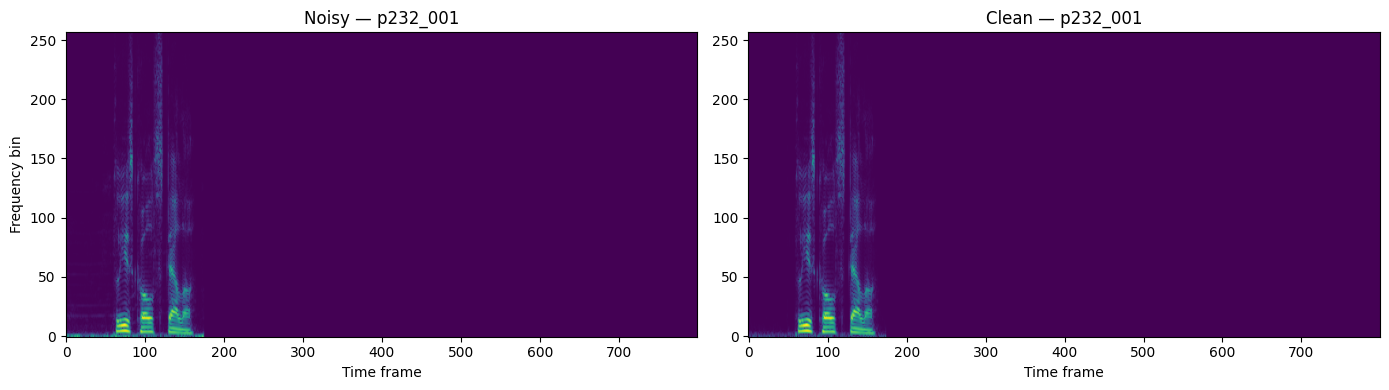

In [24]:

batch = next(iter(test_loader))

print("Batch keys:", list(batch.keys()))
print(f"noisy_mag  : {batch['noisy_mag'].shape}  dtype={batch['noisy_mag'].dtype}")
print(f"clean_mag  : {batch['clean_mag'].shape}  dtype={batch['clean_mag'].dtype}")
print(f"noisy_phase: {batch['noisy_phase'].shape}")
print(f"lengths    : {batch['lengths']}")
print(f"pair_ids   : {batch['pair_ids']}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
idx = 0
axes[0].imshow(batch["noisy_mag"][idx, 0].numpy(), aspect="auto", origin="lower")
axes[0].set_title(f"Noisy — {batch['pair_ids'][idx]}")
axes[0].set_xlabel("Time frame")
axes[0].set_ylabel("Frequency bin")
axes[1].imshow(batch["clean_mag"][idx, 0].numpy(), aspect="auto", origin="lower")
axes[1].set_title(f"Clean — {batch['pair_ids'][idx]}")
axes[1].set_xlabel("Time frame")
plt.tight_layout()
plt.show()

# 4. HuggingFace Baseline for Classifying Audio to Speech or Noise (WRONG ONE)



In [25]:
import torch
import torch.nn.functional as F
import torchaudio.transforms as T
from transformers import AutoModelForAudioClassification

# Move this outside any loops so it's only initialized once
mel_map = T.MelScale(n_mels=128, sample_rate=16000, n_stft=257)

def prepare_for_ast(noisy_mag_batch):
    """Bridge function: converts your STFT magnitudes to AST features."""
    # Logic from previous steps...
    mag = torch.expm1(noisy_mag_batch.squeeze(1))
    mel_spec = mel_map(mag)
    log_mel = torch.log(mel_spec + 1e-10).transpose(-1, -2)

    # Pad to 1024 frames (AST fixed input size)
    if log_mel.shape[1] > 1024:
        log_mel = log_mel[:, :1024, :]
    else:
        log_mel = F.pad(log_mel, (0, 0, 0, 1024 - log_mel.shape[1]))

    # Normalization (Crucial for Transformer accuracy)
    mu, std = log_mel.mean(), log_mel.std()
    return (log_mel - mu) / (std * 2 + 1e-10)

In [26]:
# Load weights once
device = "cuda" if torch.cuda.is_available() else "cpu"
model = AutoModelForAudioClassification.from_pretrained("norwoodsystems/norwood-speechVSnoise-AST-based").to(device)
model.eval()

# Run classification
for batch in test_loader:
    # 1. Transform your [B, 1, 257, T] tensors to [B, 1024, 128]
    ast_inputs = prepare_for_ast(batch["noisy_mag"]).to(device)

    # 2. Forward pass
    with torch.no_grad():
        outputs = model(ast_inputs)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1) # 0: noise, 1: speech

    # Use labels for readability
    labels = ["Noise", "Speech"]
    print(f"Results for batch {batch['pair_ids']}:")
    for i, p in enumerate(preds):
        print(f" - {batch['pair_ids'][i]}: {labels[p]}")
    break # Test on one batch first

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

Results for batch ['p232_001', 'p232_002', 'p232_003', 'p232_005', 'p232_006', 'p232_007', 'p232_009', 'p232_010']:
 - p232_001: Noise
 - p232_002: Noise
 - p232_003: Speech
 - p232_005: Speech
 - p232_006: Noise
 - p232_007: Noise
 - p232_009: Noise
 - p232_010: Noise


# 5. Denoising Baseline

In [27]:
!pip install speechbrain

In [29]:
import torch
from speechbrain.pretrained import SpectralMaskEnhancement
import torch.nn.functional as F
from tqdm import tqdm # Optional: for a progress bar

# --- INITIALIZATION ---
enhancer = SpectralMaskEnhancement.from_hparams(

source="speechbrain/metricgan-plus-voicebank",

savedir="pretrained_models"

)

metricgan_model = enhancer.mods.enhance_model

metricgan_model.eval()
total_l1_loss = 0.0
total_samples = 0

# Ensure model is on the right device
device = "cuda" if torch.cuda.is_available() else "cpu"
metricgan_model.to(device)
metricgan_model.eval()

print(f"Starting evaluation on {len(test_loader)} batches...")

# --- EVALUATION LOOP ---
with torch.no_grad():
    for batch in tqdm(test_loader):
        # 1. Prepare data (Reversing log1p for the baseline)
        noisy_mag_linear = torch.expm1(batch["noisy_mag"])
        noisy_mag_baseline = noisy_mag_linear.squeeze(1).transpose(1, 2).to(device)

        # Target for loss calculation (keep in log1p as per your project)
        target_mag = batch["clean_mag"].cpu()

        # 2. Handle lengths
        max_t = noisy_mag_baseline.shape[1]
        rel_lengths = (batch["lengths"].float() / max_t).to(device)

        # 3. Forward Pass
        mask = metricgan_model(noisy_mag_baseline, lengths=rel_lengths)

        # 4. Dimension Fix (Interpolation)
        if mask.shape[1] != max_t:
            mask = mask.transpose(1, 2)
            mask = torch.nn.functional.interpolate(mask, size=max_t, mode='linear', align_corners=False)
            mask = mask.transpose(1, 2)

        # 5. Apply Mask & Convert back to your project scale (log1p)
        enhanced_mag_linear = noisy_mag_baseline * mask
        baseline_enhanced_mag = torch.log1p(enhanced_mag_linear).cpu()

        # 6. Shape fix to match [B, 1, 257, T]
        baseline_enhanced_mag = baseline_enhanced_mag.transpose(1, 2).unsqueeze(1)

        # 7. Calculate Batch L1 Loss
        # We calculate the mean error for this specific batch
        batch_loss = F.l1_loss(baseline_enhanced_mag, target_mag)

        # Accumulate weighted by batch size to get a true average at the end
        current_batch_size = batch["noisy_mag"].size(0)
        total_l1_loss += batch_loss.item() * current_batch_size
        total_samples += current_batch_size

# --- FINAL RESULTS ---
avg_l1_loss = total_l1_loss / total_samples

print("\n" + "="*30)
print(f"FINAL EVALUATION COMPLETE")
print(f"Total Samples Processed: {total_samples}")
print(f"Average L1 Loss:         {avg_l1_loss:.6f}")
print("="*30)

/tmp/ipykernel_1128/2196187177.py:2: UserWarning: Module 'speechbrain.pretrained' was deprecated, redirecting to 'speechbrain.inference'. Please update your script. This is a change from SpeechBrain 1.0. See: https://github.com/speechbrain/speechbrain/releases/tag/v1.0.0
  from speechbrain.pretrained import SpectralMaskEnhancement
INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/metricgan-plus-voicebank' if not cached


hyperparams.yaml: 0.00B [00:00, ?B/s]

INFO:speechbrain.utils.fetching:Fetch enhance_model.ckpt: Fetching from HuggingFace Hub 'speechbrain/metricgan-plus-voicebank' if not cached


enhance_model.ckpt:   0%|          | 0.00/7.59M [00:00<?, ?B/s]

INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: enhance_model


Starting evaluation on 103 batches...


100%|██████████| 103/103 [00:04<00:00, 22.03it/s]


FINAL EVALUATION COMPLETE
Total Samples Processed: 824
Average L1 Loss:         0.035266


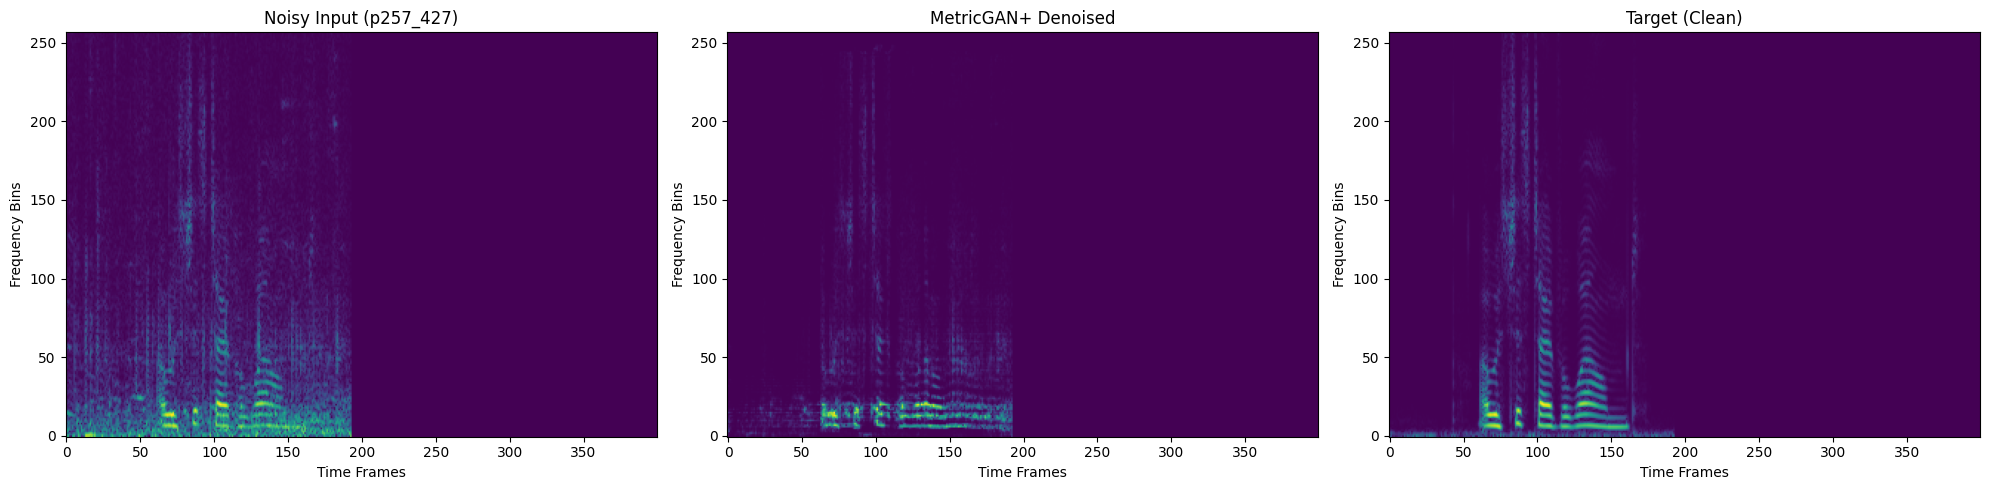

In [30]:
import matplotlib.pyplot as plt

idx = 0 # Look at the first sample in the batch
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot Noisy (Your Input)
axes[0].imshow(batch["noisy_mag"][idx, 0].cpu().numpy(), aspect="auto", origin="lower")
axes[0].set_title(f"Noisy Input ({batch['pair_ids'][idx]})")

# Plot MetricGAN+ (The Baseline)
axes[1].imshow(baseline_enhanced_mag[idx, 0].numpy(), aspect="auto", origin="lower")
axes[1].set_title("MetricGAN+ Denoised")

# Plot Clean (The Goal)
axes[2].imshow(batch["clean_mag"][idx, 0].cpu().numpy(), aspect="auto", origin="lower")
axes[2].set_title("Target (Clean)")

for ax in axes:
    ax.set_xlabel("Time Frames")
    ax.set_ylabel("Frequency Bins")

plt.tight_layout()
plt.show()

In [31]:
# 1. Combine Magnitude and Phase into a complex tensor
# baseline_enhanced_mag is log1p, so we must expm1 it back to linear
denoised_linear_mag = torch.expm1(baseline_enhanced_mag).squeeze(1)
noisy_phase = batch["noisy_phase"] # Already [B, 257, T]

# Create complex spectrogram: mag * e^(i * phase)
# Note: Ensure these are on CPU or GPU together
complex_spec = torch.polar(denoised_linear_mag, noisy_phase)

# 2. Inverse STFT to get Waveform
baseline_wavs = torch.istft(
    complex_spec,
    n_fft=512,
    hop_length=160,
    win_length=400,
    window=torch.hann_window(400).to(complex_spec.device)
)

print(f"Baseline Waveform Shape: {baseline_wavs.shape}") # Should be [B, Time_Samples]

Baseline Waveform Shape: torch.Size([8, 63840])


In [32]:
target_mag = batch["clean_mag"]

# Calculate the L1 Loss
# We use reduction='mean' to get the average error per pixel/bin
baseline_l1 = F.l1_loss(baseline_enhanced_mag, target_mag, reduction='mean')

print(f"MetricGAN+ Baseline L1 Loss: {baseline_l1.item():.4f}")

MetricGAN+ Baseline L1 Loss: 0.0351


# 4. Model Architecture

This section details the code for the architecture of our model. [Expand on this later]

Input: `noisy_mag [B, 1, 257, T]` (log-magnitude spectrogram)

Output: predicted clean magnitude (same shape), or a mask in `[0, 1]`

STFT parameters: `n_fft=512`, `hop_length=160`, `win_length=400`, `window=hann`, 257 frequency bins.